# Gaussian Naive Bayes - Pima Indians Diabetes

In [1]:
import numpy as np
import pandas as pd

In [2]:
csv_path = '/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
print('Shape:', df.shape)
df.head()

Loaded from: /kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
required_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

X = df.drop(columns=['Outcome']).to_numpy(dtype=float)
y = df['Outcome'].to_numpy(dtype=int)

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)
print('Class distribution:', {int(c): int((y == c).sum()) for c in np.unique(y)})

Feature matrix shape: (768, 8)
Target vector shape: (768,)
Class distribution: {0: 500, 1: 268}


In [4]:
def train_test_split_custom(X, y, test_size=0.25, random_state=42, shuffle=True):
    n = len(X)
    indices = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(seed=random_state)
        rng.shuffle(indices)

    test_count = int(n * test_size)
    test_idx = indices[:test_count]
    train_idx = indices[test_count:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


class GaussianNaiveBayes:
    def __init__(self, epsilon=1e-9):
        self.epsilon = epsilon
        self.classes_ = None
        self.class_prior_ = {}
        self.mean_ = {}
        self.var_ = {}

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples = X.shape[0]

        for c in self.classes_:
            X_c = X[y == c]
            self.class_prior_[c] = X_c.shape[0] / n_samples
            self.mean_[c] = X_c.mean(axis=0)
            self.var_[c] = X_c.var(axis=0) + self.epsilon

    def _gaussian_log_likelihood(self, class_label, x):
        mean = self.mean_[class_label]
        var = self.var_[class_label]

        log_term = -0.5 * np.log(2.0 * np.pi * var)
        exp_term = -((x - mean) ** 2) / (2.0 * var)
        return np.sum(log_term + exp_term)

    def _joint_log_posterior(self, x):
        scores = {}
        for c in self.classes_:
            log_prior = np.log(self.class_prior_[c])
            log_likelihood = self._gaussian_log_likelihood(c, x)
            scores[c] = log_prior + log_likelihood
        return scores

    def predict(self, X):
        preds = []
        for x in X:
            scores = self._joint_log_posterior(x)
            preds.append(max(scores, key=scores.get))
        return np.array(preds, dtype=int)


def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [5]:
X_train, X_test, y_train, y_test = train_test_split_custom(
    X, y, test_size=0.25, random_state=42, shuffle=True
)

print('Train size:', len(X_train))
print('Test size :', len(X_test))

gnb = GaussianNaiveBayes(epsilon=1e-9)
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%')

Train size: 576
Test size : 192
Accuracy: 71.35%


In [6]:
num_samples = min(10, len(X_test))
print('Sample predictions (first', num_samples, 'test rows):')
print('Index | Actual | Predicted')
for i in range(num_samples):
    print(f'{i:>5} | {y_test[i]:>6} | {y_pred[i]:>9}')

Sample predictions (first 10 test rows):
Index | Actual | Predicted
    0 |      1 |         1
    1 |      0 |         0
    2 |      1 |         1
    3 |      1 |         1
    4 |      0 |         1
    5 |      1 |         1
    6 |      0 |         0
    7 |      1 |         0
    8 |      0 |         0
    9 |      1 |         1


Confusion Matrix Values:
TP: 46 TN: 91 FP: 20 FN: 35


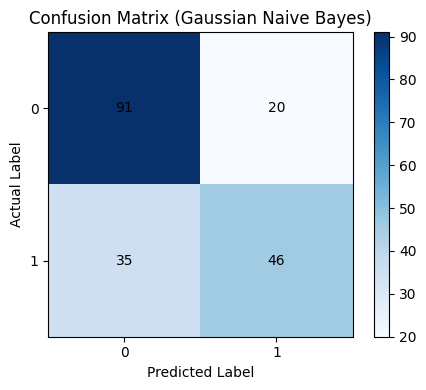

In [7]:
import matplotlib.pyplot as plt

tp = int(np.sum((y_test == 1) & (y_pred == 1)))
tn = int(np.sum((y_test == 0) & (y_pred == 0)))
fp = int(np.sum((y_test == 0) & (y_pred == 1)))
fn = int(np.sum((y_test == 1) & (y_pred == 0)))

print('Confusion Matrix Values:')
print('TP:', tp, 'TN:', tn, 'FP:', fp, 'FN:', fn)

cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

ax.set_title('Confusion Matrix (Gaussian Naive Bayes)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['0', '1'])
ax.set_yticklabels(['0', '1'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()